In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path


In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')

print(f'Using device: {device}')

Using device: mps


In [3]:
BASE_DIR = Path('.')
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'validation'
test_dir = BASE_DIR / 'test'

print('Train:', train_dir.resolve())
print('Validation:', val_dir.resolve())
print('Test:', test_dir.resolve())

assert train_dir.exists(), 'train folder not found'
assert val_dir.exists(), 'validation folder not found'
assert test_dir.exists(), 'test folder not found'

Train: /Users/ritesh/Downloads/clothing-dataset-small/train
Validation: /Users/ritesh/Downloads/clothing-dataset-small/validation
Test: /Users/ritesh/Downloads/clothing-dataset-small/test


In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Classes:', train_dataset.classes)
print('Number of classes:', len(train_dataset.classes))
print('Train images:', len(train_dataset))
print('Validation images:', len(val_dataset))
print('Test images:', len(test_dataset))

Classes: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
Number of classes: 10
Train images: 3068
Validation images: 341
Test images: 372


## Original Model


In [5]:
class OriginalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 64 * 64, 256)
        self.relu2 = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.flatten(x)
        x = self.relu2(self.fc1(x))
        x = self.fc2(x)
        return x

model = OriginalModel().to(device)
print(model)

OriginalModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=65536, out_features=256, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [6]:
def train_model(model, optimizer, criterion, epochs):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs} | loss: {train_loss:.4f} | acc: {train_acc:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

    return history

In [7]:
EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

history = train_model(model, optimizer, criterion, EPOCHS)

Epoch 1/15 | loss: 2.1189 | acc: 0.3374 | val_loss: 1.8295 | val_acc: 0.4106
Epoch 2/15 | loss: 1.5541 | acc: 0.5033 | val_loss: 1.6302 | val_acc: 0.4985
Epoch 3/15 | loss: 1.3337 | acc: 0.5668 | val_loss: 1.5433 | val_acc: 0.4868
Epoch 4/15 | loss: 1.1602 | acc: 0.6235 | val_loss: 1.4573 | val_acc: 0.5161
Epoch 5/15 | loss: 1.0104 | acc: 0.6558 | val_loss: 1.4366 | val_acc: 0.5513
Epoch 6/15 | loss: 0.8474 | acc: 0.7200 | val_loss: 1.4966 | val_acc: 0.5396
Epoch 7/15 | loss: 0.6548 | acc: 0.7956 | val_loss: 1.4079 | val_acc: 0.5865
Epoch 8/15 | loss: 0.4887 | acc: 0.8582 | val_loss: 1.3456 | val_acc: 0.6070
Epoch 9/15 | loss: 0.3486 | acc: 0.9081 | val_loss: 1.3928 | val_acc: 0.6276
Epoch 10/15 | loss: 0.2349 | acc: 0.9410 | val_loss: 1.4581 | val_acc: 0.5630
Epoch 11/15 | loss: 0.1507 | acc: 0.9729 | val_loss: 1.5985 | val_acc: 0.5513
Epoch 12/15 | loss: 0.0972 | acc: 0.9831 | val_loss: 1.6346 | val_acc: 0.5953
Epoch 13/15 | loss: 0.0617 | acc: 0.9948 | val_loss: 1.6882 | val_acc: 0.

In [8]:
def evaluate_model(model, criterion):
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    return test_running_loss / len(test_loader.dataset), test_correct / test_total

In [9]:
test_loss, test_acc = evaluate_model(model, criterion)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')


Test Loss: 2.2987
Test Accuracy: 0.4597


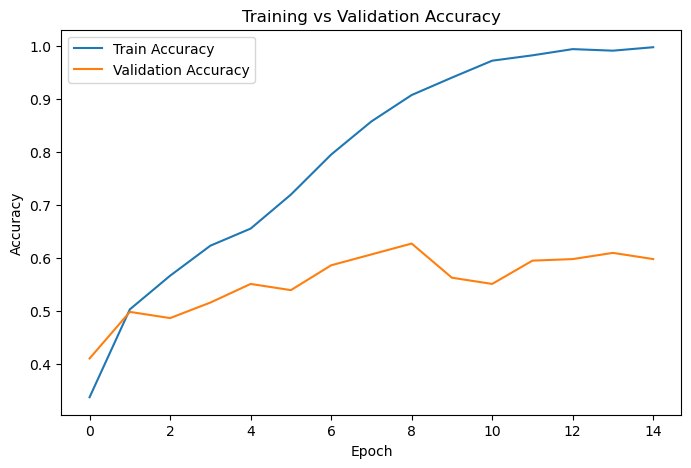

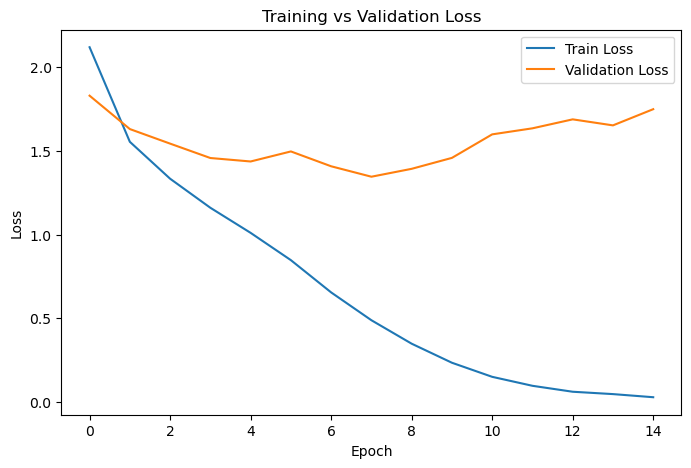

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()